In [81]:
# Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [82]:
# Carga desde un archivo .csv sin indice
lr = pd.read_csv('Leads_reales.csv', header=[2]) 

In [83]:
# Verificamos información del DataFrame
lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   33 non-null     str    
 2   Total                 31 non-null     str    
 3   Ilocalizable          32 non-null     str    
 4   No Contesta           31 non-null     str    
 5   D. Incorrectos        31 non-null     str    
 6   Duplicados            33 non-null     str    
 7   Efectivos             30 non-null     str    
 8   Abiertos              32 non-null     str    
 9   Ventas                30 non-null     str    
 10  Conversion            34 non-null     str    
 11  Efectividad de Leads  30 non-null     str    
 12  Unnamed: 12           2 non-null      float64
 13  Unnamed: 13           0 non-null      float64
dtypes: float64(3), str(11)
memory usage: 4.9 KB


In [84]:
# Limpiamos la base
lr.columns = lr.columns.str.strip()
lr["Año"] = lr["Año"].ffill()
lr["Año"] = lr["Año"].astype(int)
lr = lr[:28]
lr = lr.drop(index=0)
lr = lr.drop(columns=["Unnamed: 12", "Unnamed: 13"])

In [85]:
# Cambiamos tipos de datos
cols = ["Total","Ilocalizable","No Contesta","D. Incorrectos","Duplicados","Efectivos","Abiertos","Ventas"]
lr[cols] = lr[cols].replace(",", "", regex=True).astype(int)

lr["Conversion"] = lr["Conversion"].str.rstrip("%").astype(float)
lr["Efectividad de Leads"] = lr["Efectividad de Leads"].str.rstrip("%").astype(float)

In [86]:
# Verificamos nuevamente la información del DataFrame
lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 1 to 27
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   27 non-null     int64  
 1   Mes                   27 non-null     str    
 2   Total                 27 non-null     int64  
 3   Ilocalizable          27 non-null     int64  
 4   No Contesta           27 non-null     int64  
 5   D. Incorrectos        27 non-null     int64  
 6   Duplicados            27 non-null     int64  
 7   Efectivos             27 non-null     int64  
 8   Abiertos              27 non-null     int64  
 9   Ventas                27 non-null     int64  
 10  Conversion            27 non-null     float64
 11  Efectividad de Leads  27 non-null     float64
dtypes: float64(2), int64(9), str(1)
memory usage: 2.7 KB


In [87]:
# Calculamos el numero total de la población "n"
lr['Efectivos'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Efectivos
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [88]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=lr['Efectivos'].max()
Min=lr['Efectivos'].min()
Limites= [Min, Max]
Limites

[np.int64(128), np.int64(1040)]

In [89]:
# Calculamos el rango R
R=Max-Min
R

np.int64(912)

In [90]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.752127697007838)

In [91]:
# Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(158.5500267100133)

In [92]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(127.8, 1040.9, 6)
intervalos

array([ 127.8 ,  310.42,  493.04,  675.66,  858.28, 1040.9 ])

In [93]:
#Creamos las categorías 
categorias = ["Categoría1(127.8-310.42)", "Categoría2(310.42-493.04)", "Categoría3(493.04-675.66)",
              "Categoría4(675.66-858.28)", "Categoría5(858.28-1040.9)"]

In [94]:
# Finalmente creamos las categorías en la columna numérica
lr['Efectivos']=pd.cut(x= lr['Efectivos'], bins=intervalos, labels= categorias)
lr['Efectivos']

1     Categoría2(310.42-493.04)
2      Categoría1(127.8-310.42)
3      Categoría1(127.8-310.42)
4      Categoría1(127.8-310.42)
5     Categoría3(493.04-675.66)
6     Categoría3(493.04-675.66)
7     Categoría3(493.04-675.66)
8     Categoría3(493.04-675.66)
9     Categoría4(675.66-858.28)
10    Categoría5(858.28-1040.9)
11    Categoría5(858.28-1040.9)
12    Categoría4(675.66-858.28)
13    Categoría2(310.42-493.04)
14    Categoría4(675.66-858.28)
15    Categoría5(858.28-1040.9)
16    Categoría3(493.04-675.66)
17    Categoría4(675.66-858.28)
18    Categoría5(858.28-1040.9)
19    Categoría4(675.66-858.28)
20    Categoría3(493.04-675.66)
21    Categoría4(675.66-858.28)
22    Categoría4(675.66-858.28)
23    Categoría4(675.66-858.28)
24    Categoría4(675.66-858.28)
25    Categoría4(675.66-858.28)
26    Categoría5(858.28-1040.9)
27    Categoría4(675.66-858.28)
Name: Efectivos, dtype: category
Categories (5, str): ['Categoría1(127.8-310.42)' < 'Categoría2(310.42-493.04)' < 'Categoría3(493.04-675

In [98]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq = lr['Efectivos'].value_counts().reset_index()
Tabla_freq

,Efectivos,count
0,Categoría4(675.66-858.28),11
1,Categoría3(493.04-675.66),6
2,Categoría5(858.28-1040.9),5
3,Categoría1(127.8-310.42),3
4,Categoría2(310.42-493.04),2


In [99]:
#Ajusto el indice de mi dataframe
Tabla_freq_i = Tabla_freq.set_index('Efectivos')
Tabla_freq_i

,count
Efectivos,
Categoría4(675.66-858.28),11
Categoría3(493.04-675.66),6
Categoría5(858.28-1040.9),5
Categoría1(127.8-310.42),3
Categoría2(310.42-493.04),2


Text(0, 0.5, 'Frecuencia')

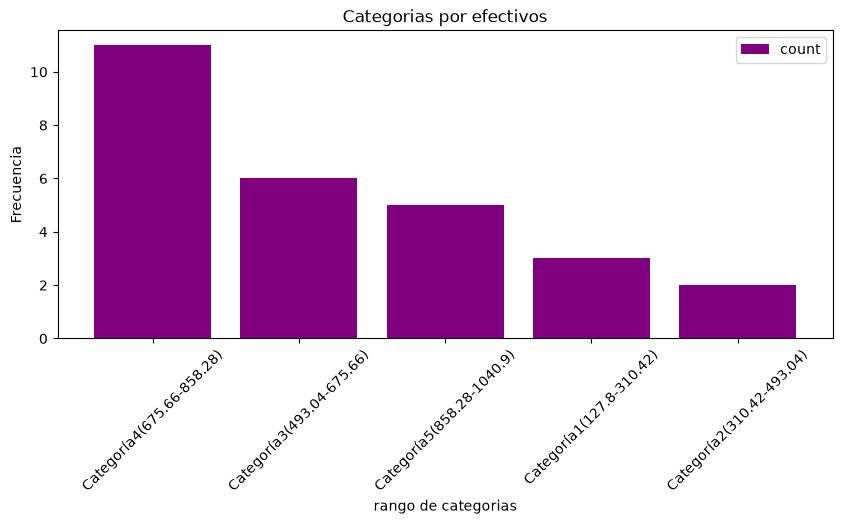

In [100]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "purple", rot=45)
plt.title('Categorias por efectivos')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')